In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Import

In [3]:
df = pd.read_csv('D:\REVISION MATERIALS\Business 360 Project\customer_shopping_behavior.csv')

### Data Exploration

In [4]:
df.shape

(3900, 18)

In [5]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [7]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [8]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [9]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x : x.fillna(x.median()))

In [10]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [67]:
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases


### Snake casing

In [12]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.rename(columns = {'purchase_amount_(usd)' : 'purchase_amount'},inplace = True)

df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [13]:
df['purchase_amount'] = df['purchase_amount']*95.97

In [14]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,5086.41,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,6142.08,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,7005.81,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,8637.30,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,4702.53,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [15]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [16]:
df.drop('promo_code_used', axis = 1, inplace = True)

*as we can see both 'discount_applied' and 'promo_code_used' are related to each other and returning same result hense drpped 'promo_code_used' to reduce redundancy*

In [17]:
df['age_group'] = pd.qcut(df['age'], q = 4, labels = ['Gen_Z','Adult','Middlae_aged','Senior'])

In [18]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group'],
      dtype='object')

In [19]:
df['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [20]:
frequency_of_days = {'Fortnightly': 14, 
                     'Weekly': 7, 
                     'Annually': 365, 
                     'Quarterly': 90, 
                     'Bi-Weekly': 14,
                     'Monthly': 30, 
                     'Every 3 Months': 90}

df['frequency_of_purchase_days'] = df['frequency_of_purchases'].map(frequency_of_days)

In [21]:
df[['frequency_of_purchases','frequency_of_purchase_days']].head()

,frequency_of_purchases,frequency_of_purchase_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365


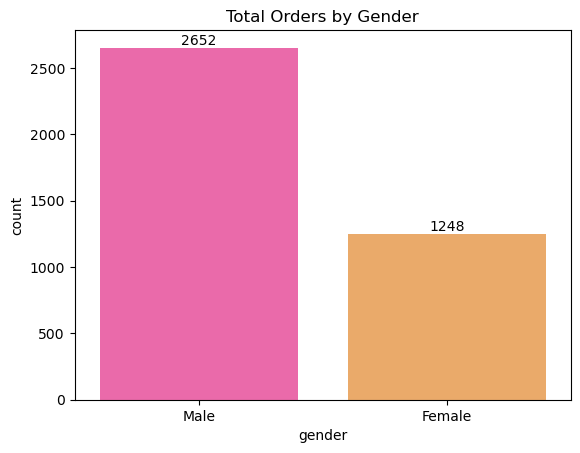

In [23]:
ax = sns.countplot(x = 'gender', data = df, hue = 'gender', palette = 'spring')
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Total Orders by Gender')
plt.show()

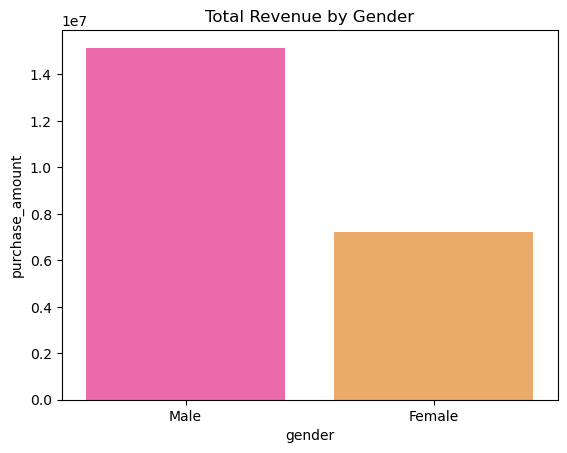

In [30]:
gen_sales = df.groupby(['gender'], as_index = False)['purchase_amount'].sum().sort_values(by = 'purchase_amount', ascending = False)

sns.barplot(x = 'gender', y = 'purchase_amount', data = gen_sales, hue = 'gender', palette = 'spring')

plt.title('Total Revenue by Gender')
plt.show()

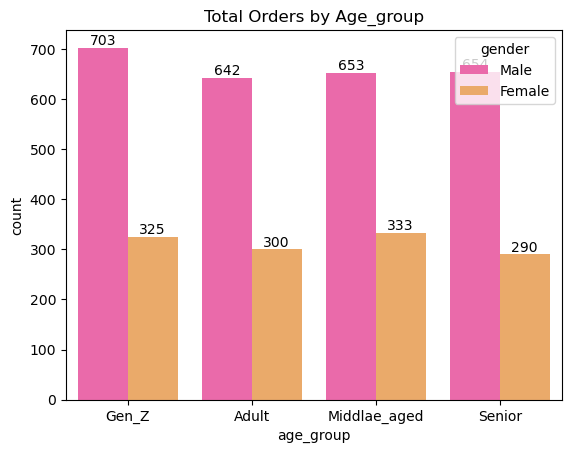

In [26]:
ax = sns.countplot(x = 'age_group', data = df, hue = 'gender', palette = 'spring')
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Total Orders by Age_group')
plt.show()

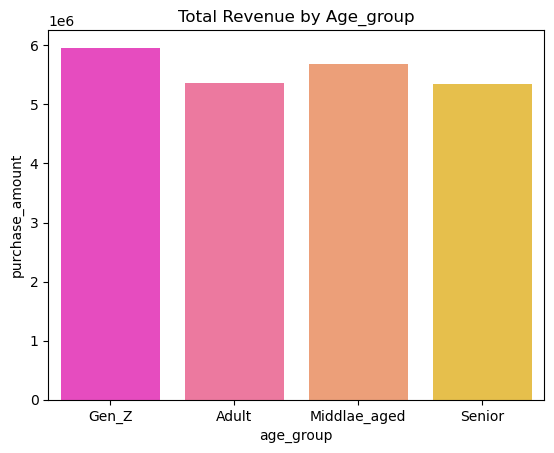

In [34]:
age_group_sales = df.groupby(['age_group'], as_index = False, observed = False)['purchase_amount'].sum().sort_values(by = 'purchase_amount', ascending = False)

sns.barplot(x = 'age_group', y = 'purchase_amount', data = age_group_sales, hue = 'age_group', palette = 'spring')

plt.title('Total Revenue by Age_group')
plt.show()

*From the above charts we can analyse that most of our buyers are Male and mostly GenZ segment are purchasing the most from us*

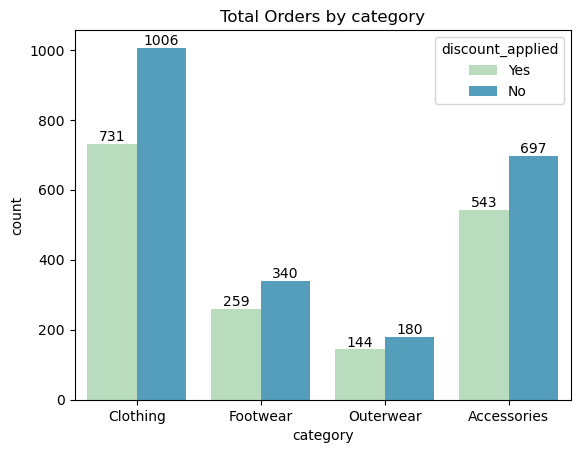

In [53]:
ax = sns.countplot(x = 'category', data = df, hue = 'discount_applied', palette = 'GnBu')
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Total Orders by category')
plt.show()

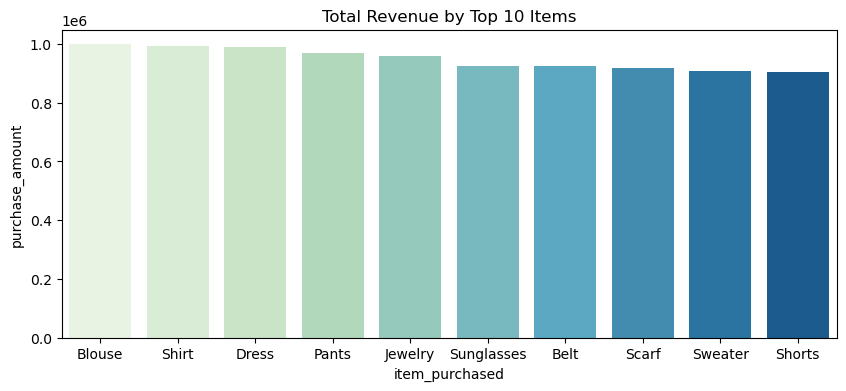

In [46]:
plt.figure(figsize = (10,4))

top_10_items = df.groupby(['item_purchased'],as_index = False)['purchase_amount'].sum().sort_values(by = 'purchase_amount', ascending = False).head(10)

sns.barplot(x = 'item_purchased', y = 'purchase_amount', data = top_10_items, hue = 'item_purchased', palette = 'GnBu')
plt.title('Total Revenue by Top 10 Items')
plt.show()

*From above graphs we can see that most prefrred products are in Clothing and Accessories and Top 10 items shows the most popular items across categories. we can also analyse that the discount is causing revenue leakage as most of the purchases are without discount*

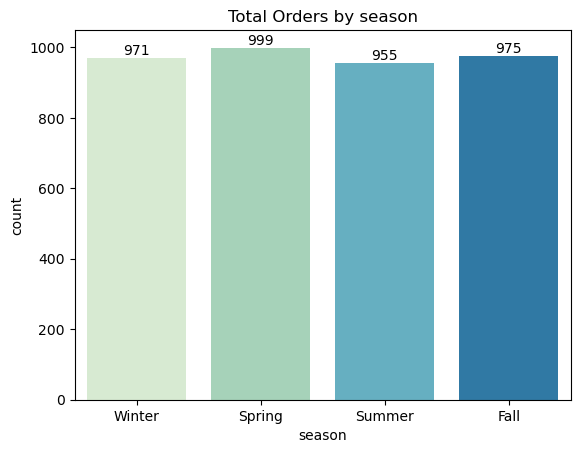

In [47]:
ax = sns.countplot(x = 'season', data = df, hue = 'season', palette = 'GnBu')
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Total Orders by season')
plt.show()

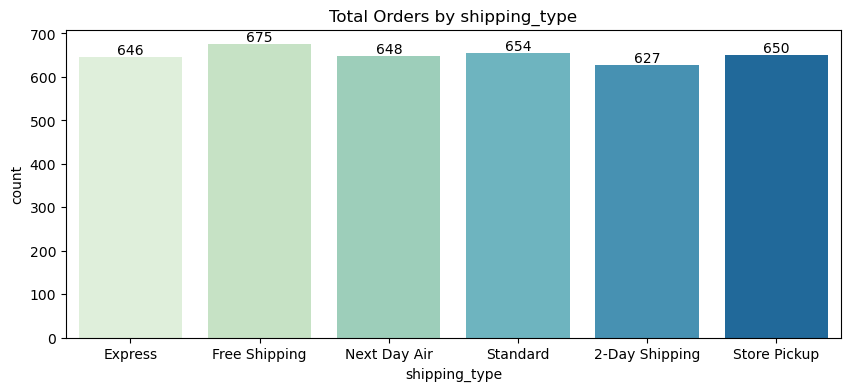

In [50]:
plt.figure(figsize = (10,4))

ax = sns.countplot(x = 'shipping_type', data = df, hue = 'shipping_type', palette = 'GnBu')
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Total Orders by shipping_type')
plt.show()

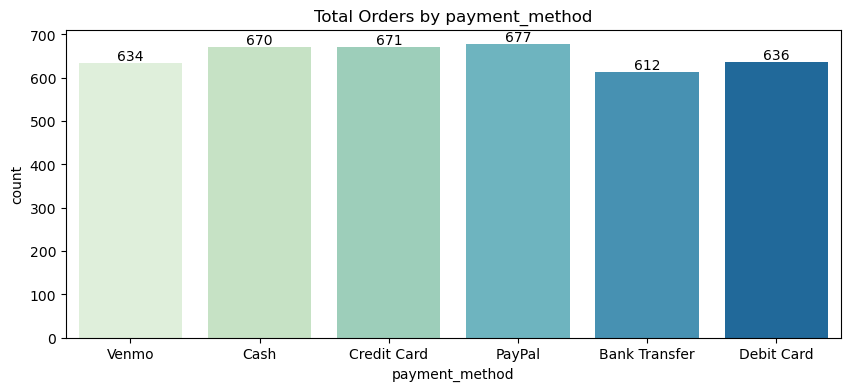

In [51]:
plt.figure(figsize = (10,4))

ax = sns.countplot(x = 'payment_method', data = df, hue = 'payment_method', palette = 'GnBu')
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Total Orders by payment_method')
plt.show()

*From above graphs we can see that most prefrred Payment Methods are PayPal,cash and Credit card and most prefrred Shipping Methods are Free Shipping, Expree shipping and Standard Shipping and sales peaks in Spring Season*

In [48]:
!pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 5.2 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 4.5 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.8 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 4.6 MB/s  0:00:01


In [81]:
from sqlalchemy import create_engine

username = "postgres"      # default user
password = urllib.parse.quote_plus("Ankita@SQL97") # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "Online retail customer analysis"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer_shopping_purchase_insights"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")



Data successfully loaded into table 'customer_shopping_purchase_insights' in database 'Online retail customer analysis'.
